<a href="https://colab.research.google.com/github/theMorana/HSE/blob/main/Machine_Learning/Semester_2_Homeworks/ML_Hometask_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

#Часть 1. K-Means

In [ ]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-04-23 10:48:52--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.002s  

2026-04-23 10:48:52 (38.6 MB/s) - ‘wineqr.csv’ saved [84143/84143]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('wineqr.csv')
X = df.drop(columns=['quality'])

In [ ]:
# mасштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [ ]:
X_scaled[0]

array([-0.52835961,  0.96187667, -1.39147228, -0.45321841, -0.24370669,
       -0.46619252, -0.37913269,  0.55827446,  1.28864292, -0.57920652,
       -0.96024611])

In [ ]:
#k-means

range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


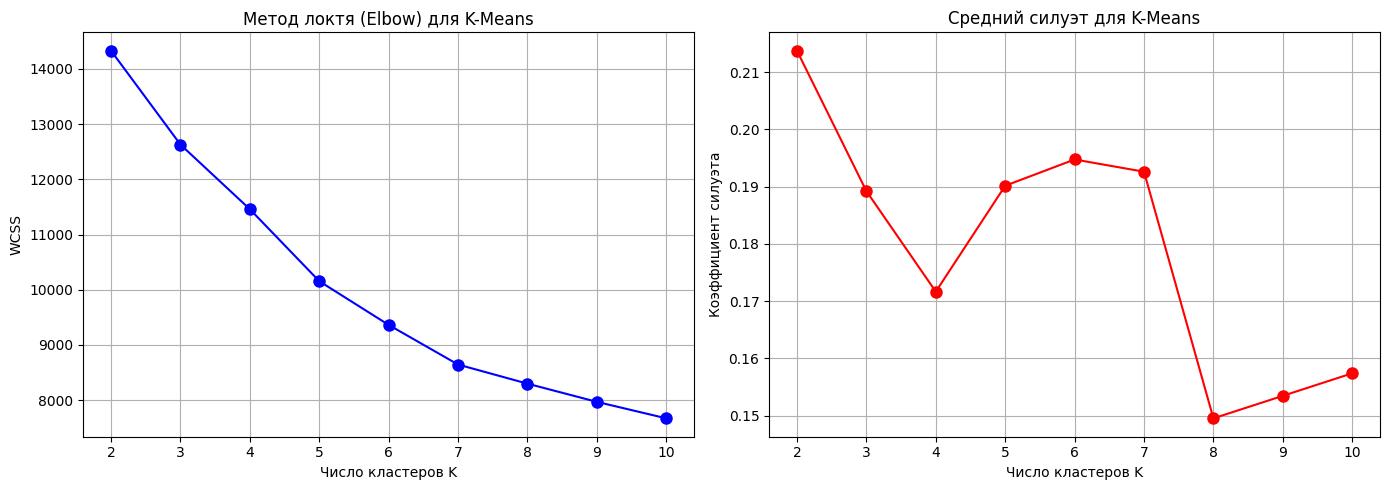

In [ ]:
#visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 2


In [ ]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

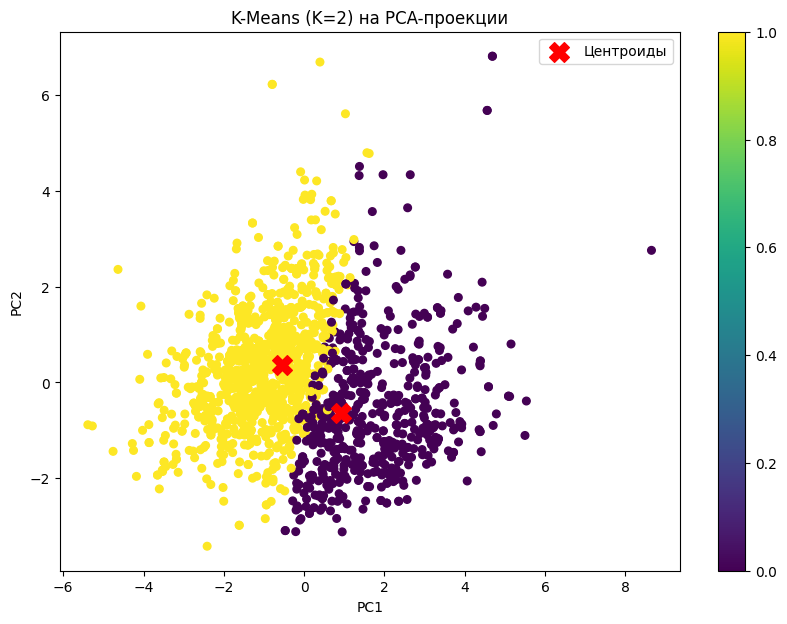

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

#Часть 2. DBSCAN

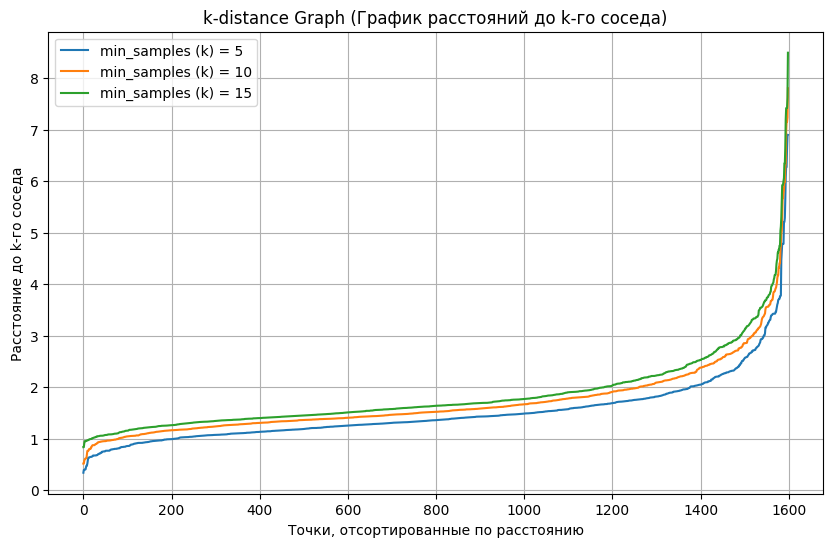

In [ ]:
def plot_k_distance_graph(X_scaled, k_values=[5, 10, 15]):
    """
    Строит графики k-расстояний для заданных значений k (min_samples).
    """
    plt.figure(figsize=(10, 6))

    for k in k_values:
        neigh = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
        neigh.fit(X_scaled)
        distances, _ = neigh.kneighbors(X_scaled)
        k_distances = distances[:, k]

        # сортировка расстояния по возрастанию
        k_distances_sorted = np.sort(k_distances)

        plt.plot(k_distances_sorted, label=f'min_samples (k) = {k}')

    plt.title('k-distance Graph (График расстояний до k-го соседа)')
    plt.xlabel('Точки, отсортированные по расстоянию')
    plt.ylabel(f'Расстояние до k-го соседа')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_k_distance_graph(X_scaled, k_values=[5, 10, 15])

In [ ]:
eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_values = [5, 10, 15]
results = []

for min_samples in min_samples_values:
    for eps in eps_values:
        # обучение
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)

        if n_clusters >= 2 and noise_ratio <= 0.8:
            try:
                silhouette = silhouette_score(X_scaled, labels)
                results.append({
                    'eps': eps,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters,
                    'noise_ratio': noise_ratio,
                    'silhouette_score': silhouette
                })

                '''
                #это была проверка
                print(f"eps={eps:.1f}, min_samples={min_samples}: "
                      f"кластеров={n_clusters}, шум={noise_ratio:.1%}, "
                      f"силуэт={silhouette:.3f}")
                '''
            except:
                pass
        else:
          '''
            print(f"eps={eps:.1f}, min_samples={min_samples}: "
                  f"кластеров={n_clusters} (отбрасываем), шум={noise_ratio:.1%}")
          '''

best_result = max(results, key=lambda x: x['silhouette_score'])
print("\nЛучшие параметры:")
print(f" eps = {best_result['eps']}")
print(f" min_samples = {best_result['min_samples']}")
print(f" Количество кластеров: {best_result['n_clusters']}")
print(f" Доля шума: {best_result['noise_ratio']:.1%}")
print(f" Оценка силуэта: {best_result['silhouette_score']:.3f}")



Лучшие параметры:
 eps = 1.1000000000000003
 min_samples = 10
 Количество кластеров: 7
 Доля шума: 77.2%
 Оценка силуэта: -0.224


In [ ]:
#обучение на лучших параметрах
best_eps = best_result['eps']
best_min_samples = best_result['min_samples']

final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_dbscan.fit_predict(X_scaled)


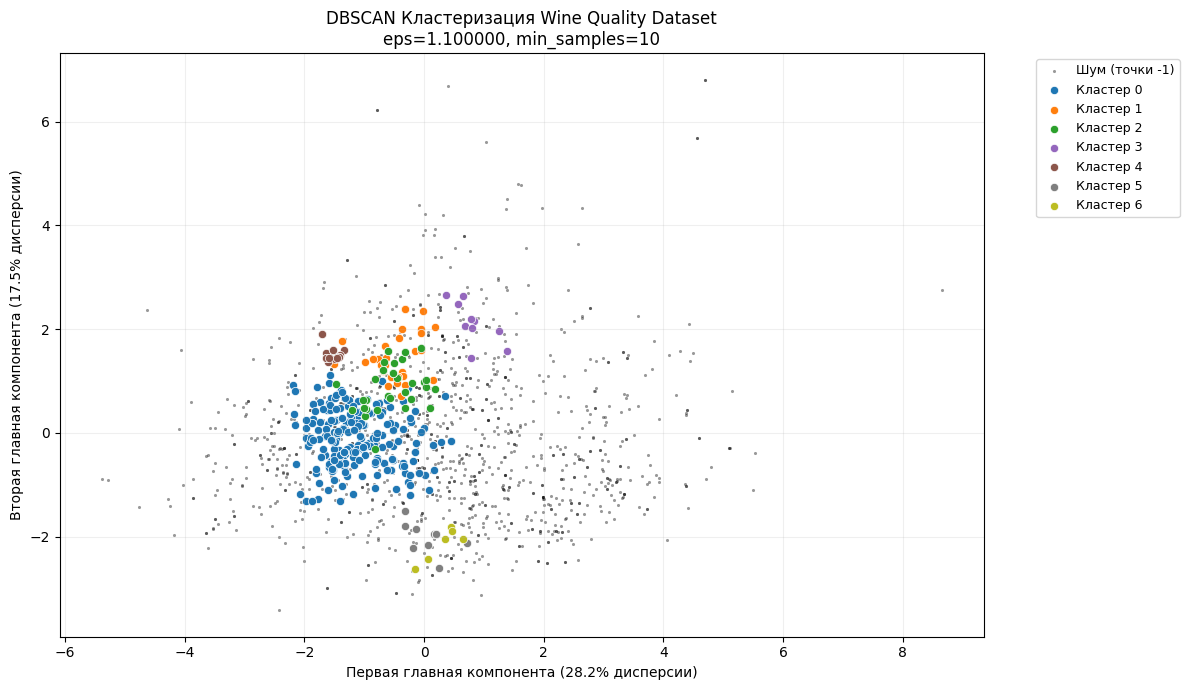

In [ ]:
#визуализация
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(12, 7))
unique_labels = set(final_labels)
n_unique = len(unique_labels)

colors_list = plt.cm.tab10(np.linspace(0, 1, n_unique))

for idx, label in enumerate(sorted(unique_labels)):
    if label == -1:
        mask = final_labels == -1
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c='black', marker='.', s=20, alpha=0.4,
                   label=f'Шум (точки -1)', linewidth=0)
    else:
        mask = final_labels == label
        color = colors_list[idx if label == -1 else idx - 1]
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], marker='o', s=35,
                   edgecolors='white', linewidth=0.5,
                   label=f'Кластер {label}')

plt.title(f'DBSCAN Кластеризация Wine Quality Dataset\n'
          f'eps={best_eps:1f}, min_samples={best_min_samples}')
plt.xlabel(f'Первая главная компонента ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'Вторая главная компонента ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


##Ответы на вопросы

1. Для DBSCAN необходимо масштабирование данных из-за того, что для параметра eps очень важна размерность - если признаки имеют разные масштабы, то признак с большим масштабом будет практически полностью определять расстояние между точками. Поэтому мы производим масштабирование и "выравниваем" признаки. Без масштабирования DBSCAN может либо не найти ни одного кластера (при маленьком eps), либо слить все точки в один кластер (при большом eps).
2. При маленьком eps может не найтись ни одного кластера, а при большом все точки могут слиться в один  кластер. Важно правильно подобрать расстояние между точками для формирования их в кластеры правильно.
3. Точки с меткой -1 обозначают шум (или выбросы) - точки, которые не являются ядровыми и не попали ни в один кластер (находятся в области с низкой плотностью).
4. В отличие от K-Means, где кластеры имеют исключительно округлую форму, DBSCAN позволяет создавать кластеры разных форм, а также допускает наличие шума.

#Часть 3. OPTI

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_samples = X_scaled.shape[0]
min_cluster_size_param = max(2, int(0.05 * n_samples))  # минимум 2 образца, как требует документация

optics = OPTICS(min_samples=10,
                xi=0.05,
                min_cluster_size=min_cluster_size_param,
                cluster_method='xi')

#обучение
clusters = optics.fit_predict(X_scaled)


n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({(n_noise/n_samples)*100:.1f}%)")

# коэффициент силуэта (только если есть хотя бы 2 кластера и не все точки - шум)
if n_clusters >= 2 and n_noise < n_samples:
    mask = clusters != -1
    if mask.sum() >= 2:
        sil_score = silhouette_score(X_scaled[mask], clusters[mask])
        print(f"Коэффициент силуэта: {sil_score:.3f}")
    else:
        print("Недостаточно точек для расчета коэффициента силуэта")
else:
    print("Коэффициент силуэта не может быть рассчитан (менее 2 кластеров или все точки - шум)")

Количество найденных кластеров: 1
Количество шумовых точек: 0 (0.0%)
Коэффициент силуэта не может быть рассчитан (менее 2 кластеров или все точки - шум)


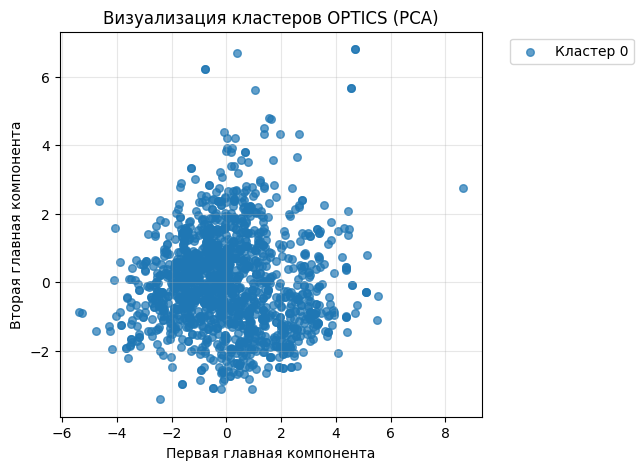

In [ ]:
# визуализация кластеров через PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
unique_clusters = np.unique(clusters)
for cluster in unique_clusters:
    mask = clusters == cluster
    if cluster == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c='gray', label='Шум', alpha=0.5, s=20)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'Кластер {cluster}', alpha=0.7, s=30)
plt.title('Визуализация кластеров OPTICS (PCA)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)


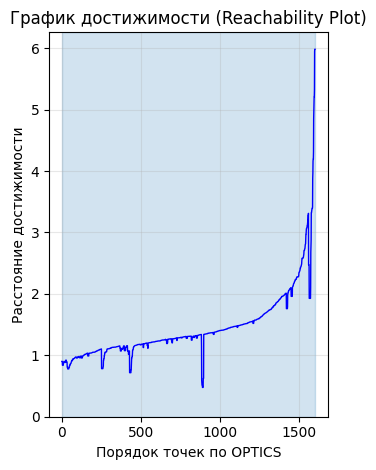

In [ ]:
#график достижимости
plt.subplot(1, 2, 2)
order = optics.ordering_
reachability = optics.reachability_[order]

plt.plot(range(len(reachability)), reachability, 'b-', linewidth=1)

cluster_boundaries = []
current_cluster = clusters[order[0]]
start_idx = 0

for i, idx in enumerate(order):
    if clusters[idx] != current_cluster:
        if current_cluster != -1:
            cluster_boundaries.append((current_cluster, start_idx, i-1))
        start_idx = i
        current_cluster = clusters[idx]

if current_cluster != -1:
    cluster_boundaries.append((current_cluster, start_idx, len(order)-1))


colors = plt.cm.tab10(np.linspace(0, 1, n_clusters)) if n_clusters > 0 else []
for cluster_num, (cluster_id, start, end) in enumerate(cluster_boundaries):
    if cluster_id != -1:
        plt.axvspan(start, end, alpha=0.2, color=colors[cluster_num % len(colors)])

plt.title('График достижимости (Reachability Plot)')
plt.xlabel('Порядок точек по OPTICS')
plt.ylabel('Расстояние достижимости')
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

##Ответы на вопросы:
1. **Первое отличие** OPTICS от DBSCAN заключается в том, что OPTICS хранит точки в иерархической системе. С помощью параметра xi можно "вырезать" кластеры разной плотности из графика. **Второе отличие** - OPTICS не требует задания eps. Вместо этого он строит упорядоченный список точек и график достижимости, который позволяет выделять кластеры разной плотности.
2. Параметр xi — это порог крутизны (steepness threshold) для выделения кластеров на графике достижимости. Он определяет, насколько резким должен быть перепад на графике достижимости, чтобы считаться границей кластера. Если xi будет маленьким, то кластеров будет выделяться больше, и он будет чувствительнее к изменению плотности. При большои xi будут выделяться кластеры большего размера.
3. OPTICS даст лучшие результаты в сравнении с DBSCAN в задачах, связанных с разной плотностью данных. В датасете, где разные категории имеют разную плотность (например, концентрация людей в тц, спальном районе и пригороде, где расстояние между точками и их концентрация могут быть разными), DBSCAN сольёт кластеры в один большой, или не сможет правильно распределить точки.
4. DBSCAN часто работает быстрее, т.к. он не вычисляет расстояния до всех точек. Он использует структуры данных, чтобы быстро находить соседей в радиусе eps. И как только точка отнесена к кластеру, она больше никогда не анализируется заново. Тем самым он экономит время. OPTICS же вынужден строить полный порядок точек (ordering), чтобы показать иерархию плотностей.
5. На мой взгляд, лучше прошла кластеризация DBSCAN, потому что мы подобрали подходящие параметры и кластеры распределились лучше.